In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings

# Suprimir avisos de TF Hub (opcional)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("TF Hub version:", hub.__version__)

TensorFlow version: 2.16.2
TF Hub version: 0.16.1


In [3]:
# --- 1. Constantes de Pré-processamento (AJUSTADAS PARA VGGISH) ---

BATCH_SIZE = 64
SAMPLE_RATE = 16000 # Taxa de amostragem esperada pelo VGGish

# <--- MUDANÇA: Parâmetros específicos do VGGish ---
# VGGish espera 0.96s de áudio
AUDIO_DURATION_S = 0.96 
SAMPLES_PER_AUDIO = int(SAMPLE_RATE * AUDIO_DURATION_S) # 15360 amostras

# Parâmetros para STFT (VGGish usa 25ms de janela, 10ms de passo)
FRAME_LENGTH = int(SAMPLE_RATE * 0.025) # 400
FRAME_STEP = int(SAMPLE_RATE * 0.010)  # 160
N_FFT = 512 # Ou 400, mas 512 é potência de 2

# Parâmetros para Mel (VGGish usa 64 bins Mel)
N_MELS = 64
F_MIN = 125.0
F_MAX = 7500.0

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
DATA_DIR = Path('../dataset_augmented')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'

CLASS_NAMES = np.array(sorted([item.name for item in TRAIN_DIR.glob('*') if item.is_dir()]))
print(f"Classes encontradas: {CLASS_NAMES}")

Classes encontradas: ['_silence_' '_unknown_' 'go' 'no' 'off' 'on' 'stop']


In [5]:
# --- 2. Funções do Pipeline de Dados (Baseadas no mfcc_model_dev) ---

def get_label(file_path: tf.Tensor) -> tf.Tensor:
    """Extrai o rótulo (label) como um inteiro a partir do caminho do arquivo."""
    parts = tf.strings.split(file_path, '/')
    label_str = parts[-2]
    label_int = tf.argmax(label_str == CLASS_NAMES)
    return tf.cast(label_int, tf.int64)

# Esta função é idêntica à do seu notebook de referência, mas usa SAMPLES_PER_AUDIO (15360)
def decode_audio(file_path: tf.Tensor) -> tf.Tensor:
    """Lê, decodifica, normaliza e garante o comprimento fixo do áudio."""
    audio_binary = tf.io.read_file(file_path)
    audio, sr = tf.audio.decode_wav(audio_binary, desired_channels=1)
    waveform = tf.squeeze(audio, axis=-1)
    waveform = tf.cast(waveform, tf.float32)
    current_len = tf.shape(waveform)[0]

    if current_len < SAMPLES_PER_AUDIO:
        padding = tf.zeros(SAMPLES_PER_AUDIO - current_len, dtype=tf.float32)
        waveform = tf.concat([waveform, padding], 0)
    
    waveform = waveform[:SAMPLES_PER_AUDIO]
    waveform.set_shape([SAMPLES_PER_AUDIO])
    return waveform

# <--- MUDANÇA: A extração de features (MFCC) é removida daqui ---
# O pipeline agora retorna o waveform bruto, que será a entrada da camada VGGish.
def process_path(file_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Função principal que combina todas as etapas de processamento."""
    label = get_label(file_path)
    waveform = decode_audio(file_path)
    # Retorna o waveform bruto como feature
    return waveform, label

# Esta função é idêntica à do seu notebook de referência
def create_dataset(data_path: Path, shuffle: bool = True):
    """Cria um tf.data.Dataset otimizado a partir de um diretório."""
    ds = tf.data.Dataset.list_files(str(data_path / '*/*.wav'), shuffle=shuffle)
    ds = ds.map(process_path, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

In [6]:
train_ds = create_dataset(TRAIN_DIR, shuffle=True)
valid_ds = create_dataset(VALID_DIR, shuffle=False)
test_ds = create_dataset(TEST_DIR, shuffle=False)


--- Verificação do Pipeline ---
Shape do lote de Waveforms: (64, 15360)
Shape do lote de labels: (64,)
Shape de um único Waveform (Input Shape): (15360,)
Label do primeiro item do lote: 5 (on)


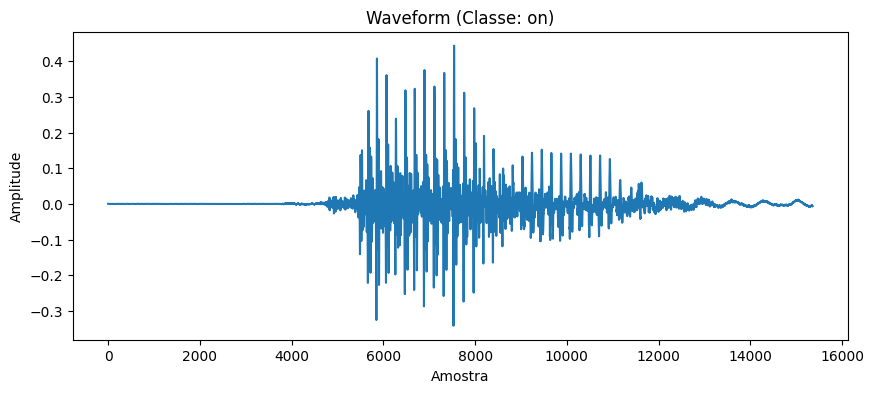

In [7]:
# --- 4. Verificação do Pipeline (Adaptado para Waveform) ---

print("\n--- Verificação do Pipeline ---")
for waveforms, labels in train_ds.take(1):
    input_shape = waveforms.shape[1:] # A entrada do modelo será o shape de um waveform
    print(f"Shape do lote de Waveforms: {waveforms.shape}")
    print(f"Shape do lote de labels: {labels.shape}")
    print(f"Shape de um único Waveform (Input Shape): {input_shape}")
    
    first_label = labels[0]
    print(f"Label do primeiro item do lote: {first_label.numpy()} ({CLASS_NAMES[first_label]})")

    plt.figure(figsize=(10, 4))
    plt.plot(waveforms[0].numpy())
    plt.title(f"Waveform (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Amplitude")
    plt.xlabel("Amostra")
    plt.show()
    break

In [10]:
# --- Definições de Tamanho ---
# O tamanho real da sua entrada (1s @ 16kHz)
SAMPLES_PER_AUDIO = 16000
# O tamanho que o VGGish exige (0.96s @ 16kHz)
VGGISH_EXPECTED_SAMPLES = 15360

# Calcular o quanto precisamos cortar
# (16000 - 15360) = 640 amostras
crop_total = SAMPLES_PER_AUDIO - VGGISH_EXPECTED_SAMPLES
if crop_total < 0:
    raise ValueError(f"Seu áudio ({SAMPLES_PER_AUDIO}) é menor que o esperado pelo VGGish ({VGGISH_EXPECTED_SAMPLES}).")

# Dividimos o corte igualmente (320 no início, 320 no fim)
crop_start = crop_total // 2
crop_end = crop_total - crop_start


# --- Parte 2: Construção do Modelo (API Funcional) ---

print("Construindo modelo com VGGish e Cropping...")

# 1. Camada de Input: Aceita SEU formato de dados (16.000)
inputs = tf.keras.layers.Input(shape=(SAMPLES_PER_AUDIO,), name="input_audio_16k")

# 2. Camada de Corte: Ajusta de 16.000 -> 15.360

x = tf.keras.layers.Lambda(
    lambda tensor: tensor[:, crop_start:-crop_end],
    name="slice_to_15360"
)(inputs)

# 3. Camada VGGish
# Esta camada recebe o tensor com o shape (None, 15360)
vggish_layer = hub.KerasLayer(
    "https://tfhub.dev/google/vggish/embedding/1",
    trainable=False,
    name="vggish_embedding"
)
x = vggish_layer(x)

# 4. Cabeça de Classificação
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# 5. Camada de Saída
outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax', name="output")(x)

# 6. Criação do Modelo
model_vggish = tf.keras.Model(inputs=inputs, outputs=outputs)

model_vggish.summary()

Construindo modelo com VGGish e Cropping...


OSError: https://tfhub.dev/google/vggish/embedding/1 does not appear to be a valid module.

In [ ]:
model_vggish.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../models/model_vggish_aug.keras', monitor='val_loss', save_best_only=True)
]

In [ ]:
history = model_vggish.fit(
    train_ds, 
    validation_data=val_ds, 
    callbacks=callbacks, 
    epochs=100, 
    verbose=1
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
model_vggish_best = tf.keras.models.load_model('../models/model_vggish_aug.keras')

y_pred_probs = model_vggish_best.predict(test_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds], axis=0)

In [ ]:
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

In [ ]:
cm = confusion_matrix(y_true_indices, y_pred_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão (VGGish + Data Aug)')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()